# COVID-19 Exploratory Data Analysis

#### This notebook explores the cleaned COVID-19 dataset and investigates
#### the research questions defined for the project.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv(
    "../data/processed/covid_cleaned.csv",
    parse_dates=["Date"]
)

df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region,Data Inconsistent
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean,False
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe,False
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa,False
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe,False
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa,False


In [7]:
country_df = (
    df.groupby(["Country/Region", "Date"], as_index=False)[
        ["Confirmed", "Deaths", "Recovered", "Active"]
    ]
    .sum()
)

In [10]:
country_df

,Country/Region,Date,Confirmed,Deaths,Recovered,Active
0,Afghanistan,2020-01-22,0,0,0,0
1,Afghanistan,2020-01-23,0,0,0,0
2,Afghanistan,2020-01-24,0,0,0,0
3,Afghanistan,2020-01-25,0,0,0,0
4,Afghanistan,2020-01-26,0,0,0,0
...,...,...,...,...,...,...
35151,Zimbabwe,2020-07-23,2124,28,510,1586
35152,Zimbabwe,2020-07-24,2296,32,514,1750
35153,Zimbabwe,2020-07-25,2434,34,518,1882
35154,Zimbabwe,2020-07-26,2512,34,518,1960


## Q1 — How did COVID-19 cases change globally over time?

In [13]:
daily_totals = (
    country_df.groupby('Date', as_index=False)[
        ["Confirmed", "Deaths", "Recovered", "Active"]
    ]
    .sum()
)

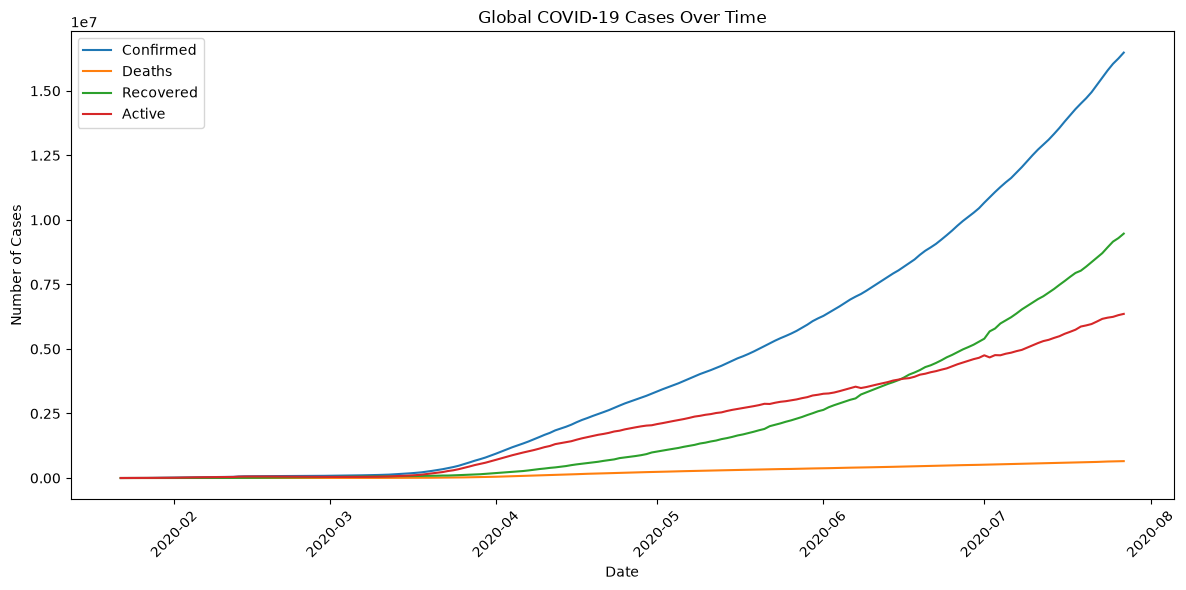

In [17]:
plt.figure(figsize=(12,6))

plt.plot(
    daily_totals['Date'],
    daily_totals['Confirmed'],
    label='Confirmed'
)

plt.plot(
    daily_totals['Date'],
    daily_totals['Deaths'],
    label='Deaths'
)

plt.plot(
    daily_totals['Date'],
    daily_totals['Recovered'],
    label='Recovered'
)

plt.plot(
    daily_totals['Date'],
    daily_totals['Active'],
    label='Active'
)

plt.xlabel('Date')
plt.ylabel('Number of Cases')
plt.title('Global COVID-19 Cases Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [18]:
daily_totals["New Confirmed"] = daily_totals["Confirmed"].diff()

In [19]:
daily_totals.head()

,Date,Confirmed,Deaths,Recovered,Active,New Confirmed
0,2020-01-22,555,17,28,510,NaN
1,2020-01-23,654,18,30,606,99.0
2,2020-01-24,941,26,36,879,287.0
3,2020-01-25,1434,42,39,1353,493.0
4,2020-01-26,2118,56,52,2010,684.0


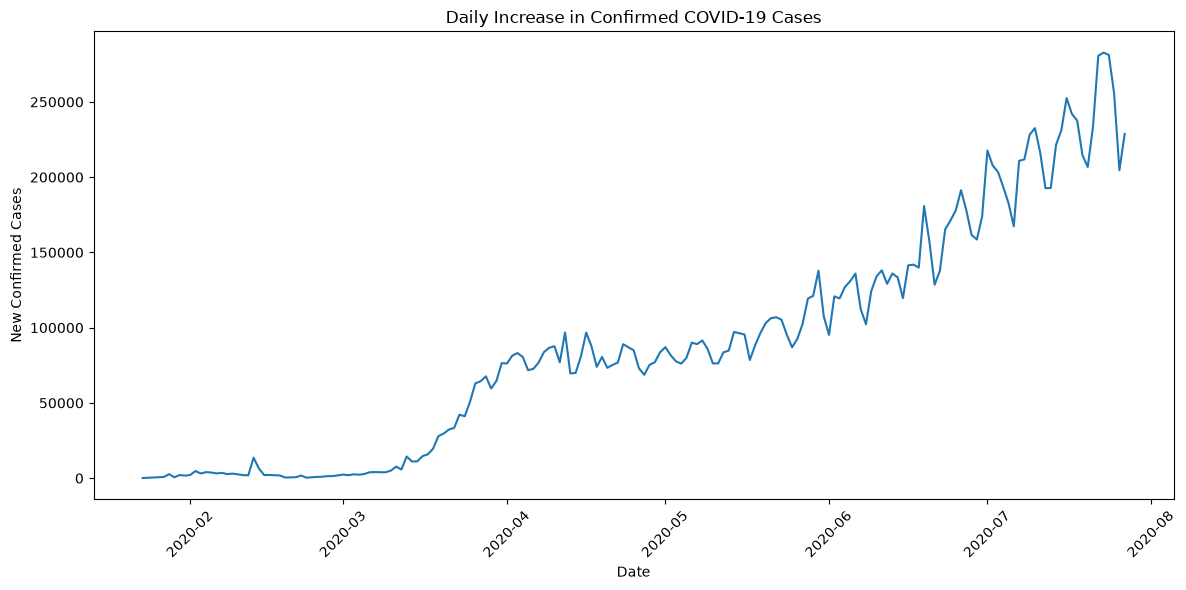

In [23]:
plt.figure(figsize=(12,6))

plt.plot(
    daily_totals['Date'],
    daily_totals['New Confirmed']
)

plt.xlabel('Date')
plt.ylabel('New Confirmed Cases')
plt.title('Daily Increase in Confirmed COVID-19 Cases')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Q1 Findings

The analysis shows how the cumulative number of confirmed cases,
deaths, recovered cases, and active cases changed throughout the
period from January 22, 2020 to July 27, 2020.

The daily increase in confirmed cases also shows how the pace of
reported infections changed during the period.

## Q2 — Which countries were most affected by COVID-19?

In [26]:
country_totals = (
    country_df.groupby('Country/Region', as_index=False)[
        ['Confirmed', 'Deaths', 'Recovered', 'Active']
    ]
    .max()
)

#### Which 10 countries had the highest reported totals during the observation period?

In [28]:
top_confirmed = (
    country_totals
    .nlargest(10, 'Confirmed')
    [['Country/Region', 'Confirmed']]
)

top_confirmed

,Country/Region,Confirmed
173,US,4290259
23,Brazil,2442375
79,India,1480073
138,Russia,816680
154,South Africa,452529
111,Mexico,395489
132,Peru,389717
35,Chile,347923
177,United Kingdom,301708
81,Iran,293606


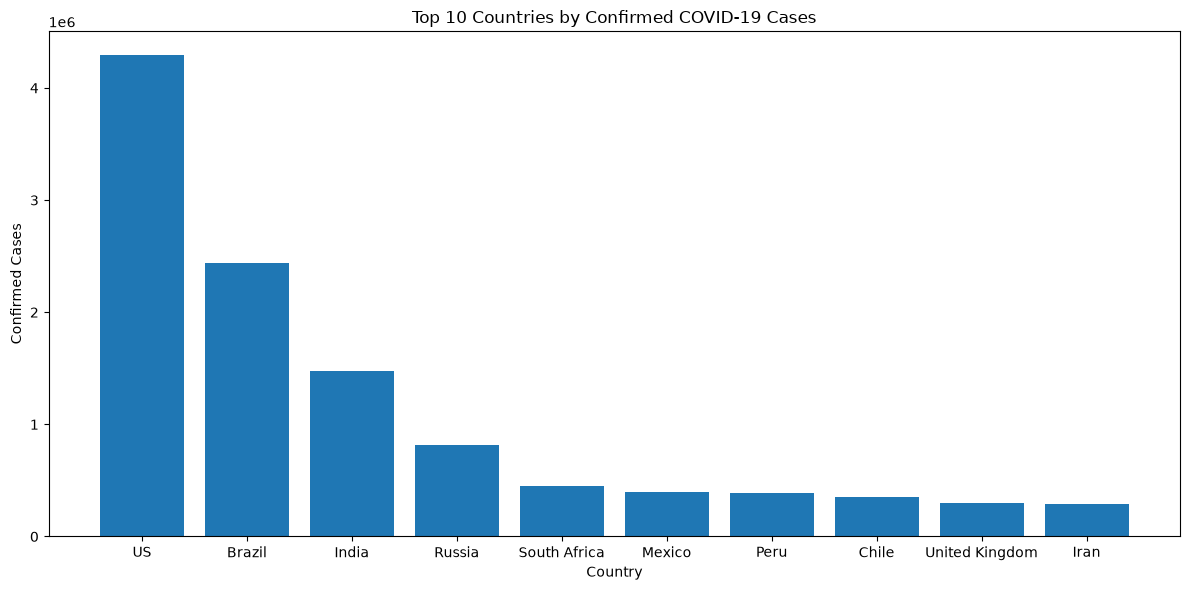

In [32]:
plt.figure(figsize=(12,6))

plt.bar(
    top_confirmed['Country/Region'],
    top_confirmed['Confirmed']
)

plt.xlabel('Country')
plt.ylabel('Confirmed Cases')
plt.title('Top 10 Countries by Confirmed COVID-19 Cases')

plt.tight_layout()
plt.show()

#### Which 10 countries had the highest death totals during the observation period?

In [34]:
top_deaths = (
    country_totals
    .nlargest(10, 'Deaths')
    [['Country/Region', 'Deaths']]
)

top_deaths

,Country/Region,Deaths
173,US,148011
23,Brazil,87618
177,United Kingdom,45844
111,Mexico,44022
85,Italy,35112
79,India,33408
61,France,30212
157,Spain,28752
132,Peru,18418
81,Iran,15912


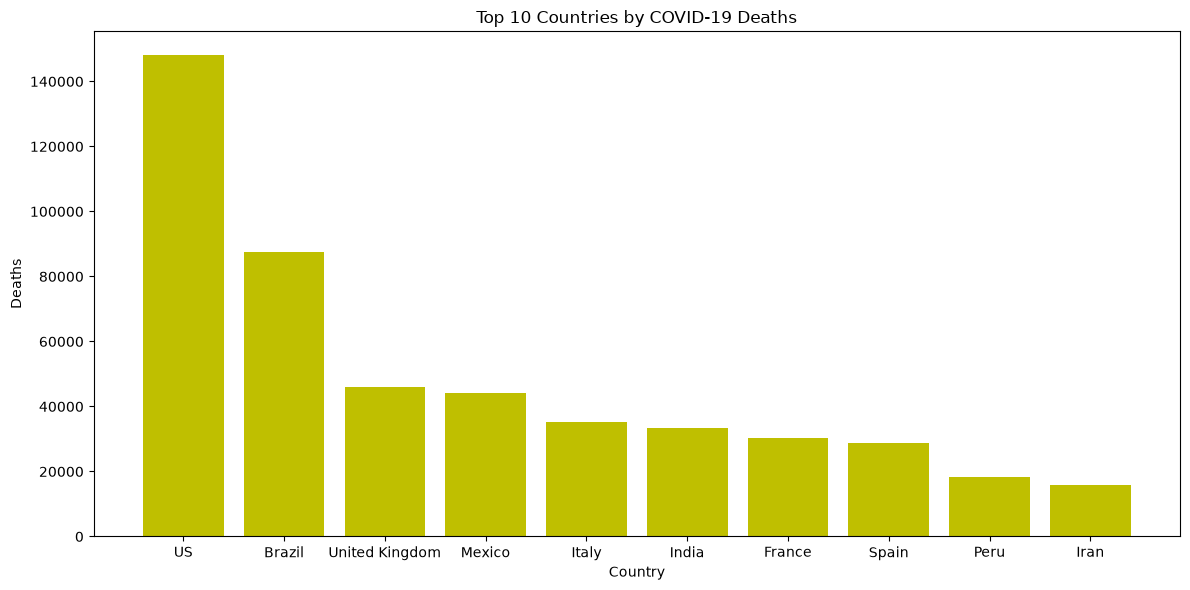

In [37]:
plt.figure(figsize=(12,6))

plt.bar(
    top_deaths['Country/Region'],
    top_deaths['Deaths'],
    color='y'
)

plt.xlabel('Country')
plt.ylabel('Deaths')
plt.title('Top 10 Countries by COVID-19 Deaths')

plt.tight_layout()
plt.show()

#### Which 10 countries had the highest recovery totals during the observation period?

In [40]:
top_recovered = (
    country_totals
    .nlargest(10, 'Recovered')
    [['Country/Region', 'Recovered']]
)

top_recovered

,Country/Region,Recovered
23,Brazil,1846641
173,US,1325804
79,India,951166
138,Russia,602249
35,Chile,319954
111,Mexico,303810
154,South Africa,274925
132,Peru,272547
81,Iran,255144
128,Pakistan,241026


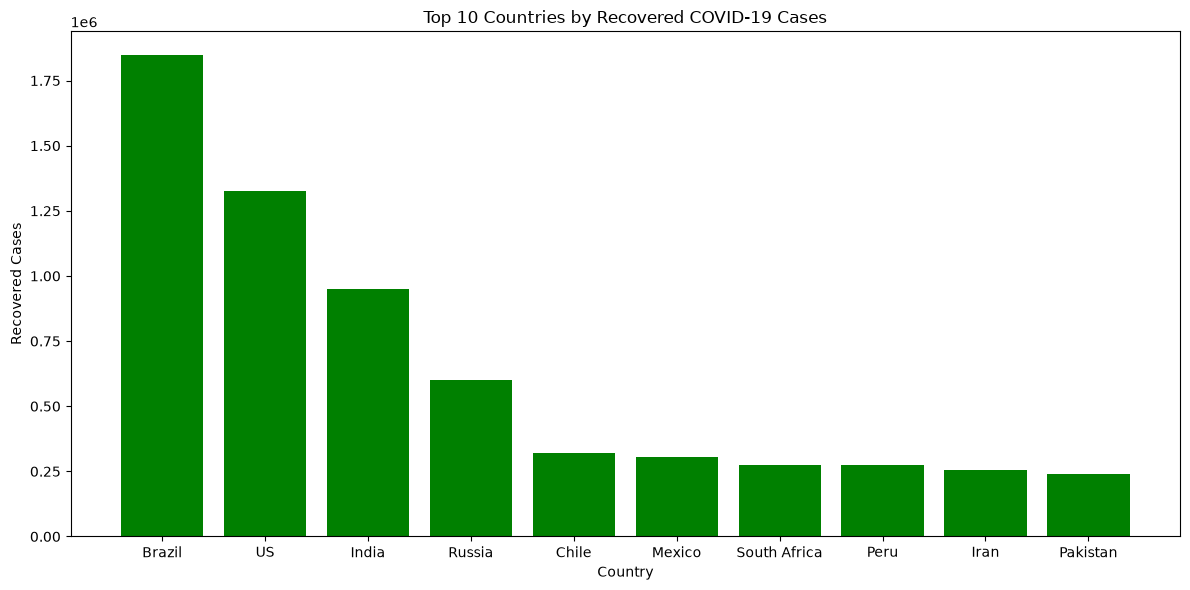

In [42]:
plt.figure(figsize=(12,6))

plt.bar(
    top_recovered['Country/Region'],
    top_recovered['Recovered'],
    color='g'
)

plt.xlabel('Country')
plt.ylabel('Recovered Cases')
plt.title('Top 10 Countries by Recovered COVID-19 Cases')

plt.tight_layout()
plt.show()

#### Which 10 countries had the highest active case totals during the observation period?

In [43]:
top_active = (
    country_totals
    .nlargest(10, 'Active')
    [['Country/Region', 'Active']]
)

top_active

,Country/Region,Active
173,US,2816444
23,Brazil,583080
79,India,495499
177,United Kingdom,254427
138,Russia,245382
154,South Africa,173590
37,Colombia,117163
61,France,108928
128,Pakistan,108642
132,Peru,108616


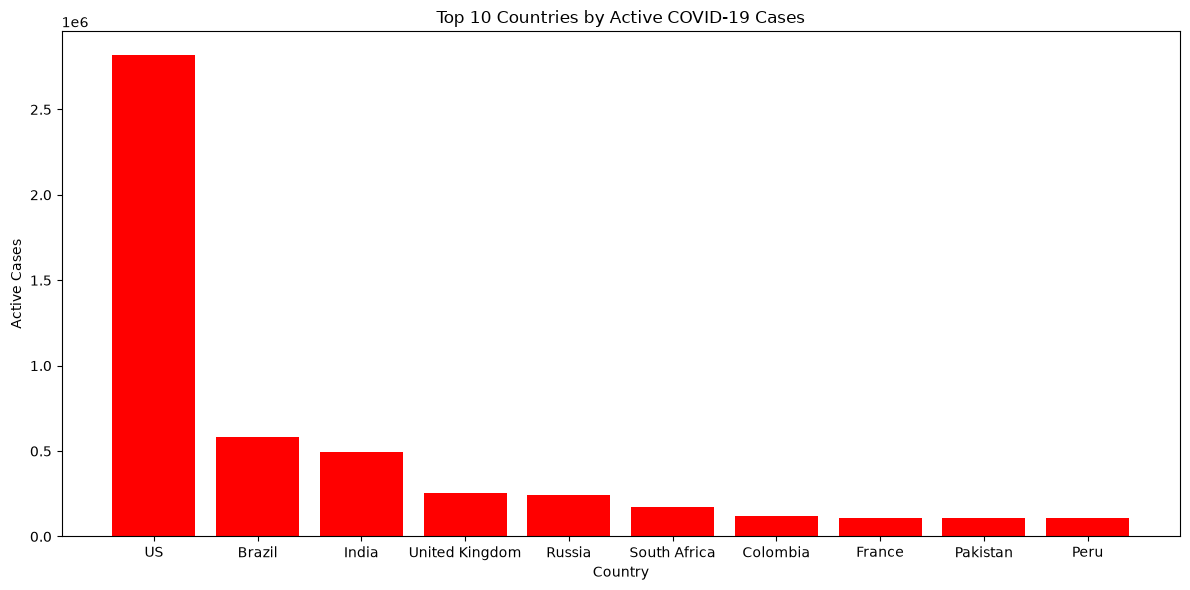

In [45]:
plt.figure(figsize=(12,6))

plt.bar(
    top_active['Country/Region'],
    top_active['Active'],
    color='r'
)

plt.xlabel('Country')
plt.ylabel('Active Cases')
plt.title('Top 10 Countries by Active COVID-19 Cases')

plt.tight_layout()
plt.show()